In [4]:
import numpy as np
import xarray as xr
#import scipy as sci
import matplotlib.pyplot as plt # still need matplotlib
import xmitgcm
import xgcm 
import gsw
import cmocean

In [2]:

# Loading .nc files with the relevant data: T, S, U, V, W 
PacPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-Physical.nc'
PacPh = xr.open_dataset(PacPhnc)

SOPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-Physical.nc'
SOPh = xr.open_dataset(SOPhnc)

conPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-Physical.nc'
conPh = xr.open_dataset(conPhnc)



In [3]:
# Time average and mask the velocities
tran = np.arange(90,100)
wvSO = xr.where(SOPh.WVEL ==0, np.nan, SOPh.WVEL).isel(time = tran).mean('time')
wvPac = xr.where(PacPh.WVEL ==0, np.nan, PacPh.WVEL).isel(time = tran).mean('time')
wvcon = xr.where(conPh.WVEL ==0, np.nan, conPh.WVEL).isel(time = tran).mean('time')

vvSO = xr.where(SOPh.VVEL ==0, np.nan, SOPh.VVEL).isel(time = tran).mean('time')
vvPac = xr.where(PacPh.VVEL ==0, np.nan, PacPh.VVEL).isel(time = tran).mean('time')
vvcon = xr.where(conPh.VVEL ==0, np.nan, conPh.VVEL).isel(time = tran).mean('time')

uvSO = xr.where(SOPh.UVEL ==0, np.nan, SOPh.UVEL).isel(time = tran).mean('time')
uvPac = xr.where(PacPh.UVEL ==0, np.nan, PacPh.UVEL).isel(time = tran).mean('time')
uvcon = xr.where(conPh.UVEL ==0, np.nan, conPh.UVEL).isel(time = tran).mean('time')


In [14]:
# Same for the temperature and salinity

THSO = xr.where(SOPh.SALT ==0, np.nan, SOPh.THETA).isel(time = tran).mean('time')
SaSO= xr.where(SOPh.SALT ==0, np.nan, SOPh.SALT).isel(time = tran).mean('time')

THPac = xr.where(PacPh.SALT ==0, np.nan, PacPh.THETA).isel(time = tran).mean('time')
SaPac= xr.where(PacPh.SALT ==0, np.nan, PacPh.SALT).isel(time = tran).mean('time')

THcon= xr.where(conPh.SALT ==0, np.nan, conPh.THETA).isel(time = tran).mean('time')
Sacon= xr.where(conPh.SALT ==0, np.nan, conPh.SALT).isel(time = tran).mean('time')

In [40]:
sigcon = gsw.sigma0(Sacon, THcon)
sigPac = gsw.sigma0(SaPac, THPac)

## Figure 8: Overturning Streamfunctions

/glade/derecho/scratch/bataylor/tmp/ipykernel_10958/3164464706.py:4: RuntimeWarning: invalid value encountered in divide
  pma = pma/pma


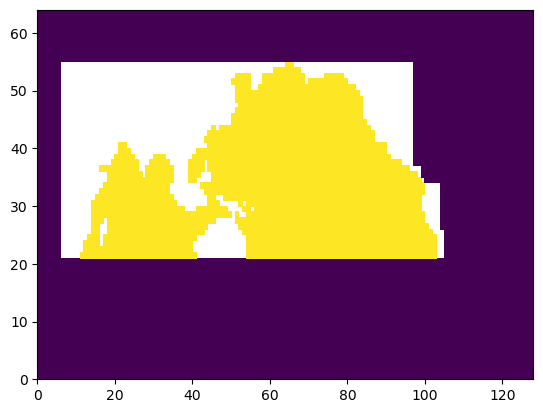

In [4]:
## define the mask for the Indian and Pacific basin 

pma = np.array(conPh.hFacC.isel(Z=0))
pma = pma/pma
#plt.pcolor(pma)


IPmask = pma
IPmask[0:21, :] = 0 
IPmask[55:64, :] = 0 
IPmask[:, 0:6] = 0 
#IPmask[:, 0:33] = 0 
IPmask[:, 105:] = 0 
IPmask[50:64, 100:] = 0 #

#AllTmask = TPmask
#IPmask[26:39, 0:36] = 0
IPmask[26:39, 104:]=0
IPmask[34:55, 100:]=0
IPmask[35:55, 99:]=0
IPmask[37:55, 97:]=0
#IPmask[17:31, 33:50] = 0
#TPmask[18:31, 33:50] = 0
plt.pcolor(IPmask)

In [6]:
# Calculating streamfunctions 

## Compute Pacific basin streamfunction
# note this creates a discontinuity at the ITF ...
masks = np.load('../Yohei_2018/forcing_files_jan25/masks.npy')
# this mask just gives each basin a different number (Similar to Fig 3). 
vconP = vvcon.where(masks==1)#.mean('time')
transport = vconP*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv = transport.sum('XC').cumsum('Z')

# Consider the Pac-4C experiment
vconPf = vvPac.where(masks==1)#.mean('time')
transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvP = transportP.sum('XC').cumsum('Z')
#netv.isel(YG=range(17,53)).plot(ylim=[-500,0])

## compute Psi using full Indo-Pacific basin
vconf = vvcon.where(IPmask==1)#.mean('time')
transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv2 = transport.sum('XC').cumsum('Z')

# Consider the SO-4C experiment
vconSf2 = vvSO.where(IPmask==1)#.mean('time')
transportS2 = vconSf2*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO2 = transportS2.sum('XC').cumsum('Z')

netdifSO2 = netvSO2 - netv2

## 

In [7]:
# For Subtropical Cell Index (STCI), only consider Pacific basin.

vconSf2 = vvSO.where(masks==1)#.mean('time')
transportS2 = vconSf2*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO3 = -transportS2.sum('XC').cumsum('Z')


print('Control STCI = ' +str((np.array(np.max(netv)) - np.array(np.min(netv)))/1e6 ))
print('Pacific-4C STCI = '+str((np.array(np.max(netvP)) - np.array(np.min(netvP)))/1e6) )
print('SO-4C STCI = '+str((np.array(np.max(netvSO3)) - np.array(np.min(netvSO3)))/1e6 ))

Control STCI = 42.925094
Pacific-4C STCI = 40.857036
SO-4C STCI = 43.32197


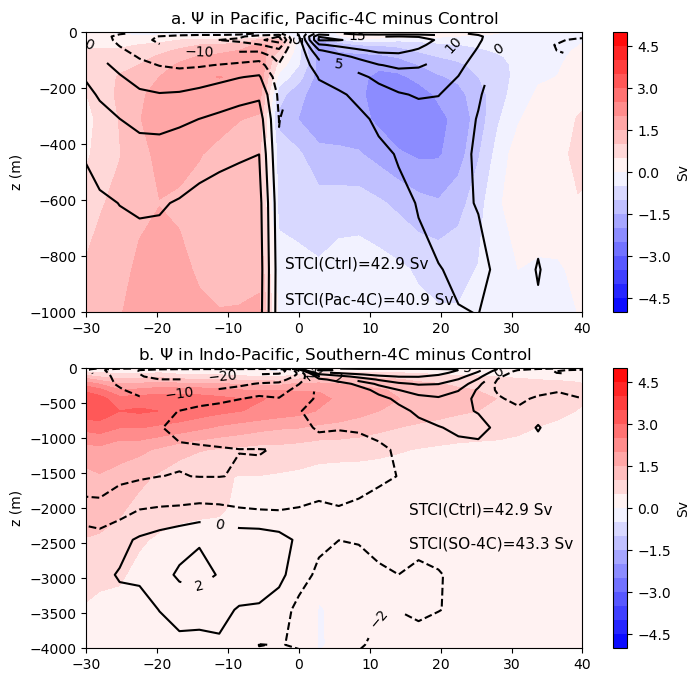

In [8]:
# Figure 8 plotting

fig, axs = plt.subplots(nrows=2, figsize=(8,8))



cl = axs[0].contour(netv.YG, netv.Z, netv/1e6, levels = np.arange(-20, 25, 5), colors= 'k')
cl.clabel()
axs[0].set_ylim([-1000,0])
axs[0].set_xlim([-30,40])
A = axs[0].contourf(netv.YG, netv.Z, (netvP - netv)/1e6, vmin = -5, vmax = 5, levels = np.linspace(-5,5,21), cmap='bwr')
cb1 = plt.colorbar(A, ax = axs[0])
cb1.set_label('Sv')
axs[0].set_title('a. $\\Psi$ in Pacific, Pacific-4C minus Control') 
axs[0].set_ylabel('z (m)')


iplevs = [-20,-10,-5,-2,0,2, 5, 10,  20]
cl2 = axs[1].contour(netv.YG, netv.Z, netv2/1e6, levels = iplevs, colors= 'k')
cl2.clabel( )
axs[1].set_ylim([-4000,0])
axs[1].set_xlim([-30,40])
B = axs[1].contourf(netv.YG, netv.Z, netdifSO2/1e6, vmin = -5, vmax = 5, levels =np.linspace(-5,5,21), cmap='bwr')
cb2= plt.colorbar(B, ax = axs[1])
cb2.set_label('Sv')
axs[1].set_title('b. $\\Psi$ in Indo-Pacific, Southern-4C minus Control')
axs[1].set_ylabel('z (m)')


#axs[0].text(0.03, 0.1, 'a', fontsize=16, transform=axs[0].transAxes, ha='left', va='top')
axs[0].text(0.4, 0.2, 'STCI(Ctrl)=42.9 Sv', fontsize=11, transform=axs[0].transAxes, ha='left', va='top')
axs[0].text(0.4, 0.07, 'STCI(Pac-4C)=40.9 Sv', fontsize=11, transform=axs[0].transAxes, ha='left', va='top')
#40.754176

#axs[1].text(0.03, 0.1, 'b', fontsize=16, transform=axs[1].transAxes, ha='left', va='top')
axs[1].text(0.65, 0.52, 'STCI(Ctrl)=42.9 Sv', fontsize=11, transform=axs[1].transAxes, ha='left', va='top')
axs[1].text(0.65, 0.4, 'STCI(SO-4C)=43.3 Sv', fontsize=11, transform=axs[1].transAxes, ha='left', va='top')


# plt.savefig('../eps_figures/Streamfunctions5-17.eps')

## Figure 7: Velocity anomaly averages under Pacific-4C 

In [36]:
## calculating speed here! 

ylow = np.arange(20,53)
myX = np.arange(64,80) # could consider 60 to 80 ...  

# here I'm converting to numpy arrays to interpolate, I guess xarray wasn't working. 
# I find the speed first, then do the zonal mean, then subtract!

myV = np.array(vvcon.isel(YG = ylow+1, XC =myX).mean('XC'))
myU = np.array(uvcon.isel(YC = ylow, XG =myX).mean('XG'))
mySpeed = ((np.array(vvcon.isel(YG = ylow+1, XC =myX)) + np.array(vvcon.isel(YG = ylow, XC =myX)))**2)/4 + \
           (np.array(uvcon.isel(YC = ylow, XG =myX)) + np.array(uvcon.isel(YC = ylow, XG =myX+1)))**2 /4
mySp = np.nanmean(mySpeed**0.5,2) # zonal average speed

# same operations but for the Pac-4C experiment
myVpac = np.array(vvPac.isel(YG = ylow+1, XC =myX).mean('XC'))
myUpac = np.array(uvPac.isel(YC = ylow, XG =myX).mean('XG'))

mySpeed = ((np.array(vvPac.isel(YG = ylow+1, XC =myX)) + np.array(vvPac.isel(YG = ylow, XC =myX)))**2)/4 + \
           (np.array(uvPac.isel(YC = ylow, XG =myX)) + np.array(uvPac.isel(YC = ylow, XG =myX+1)))**2 /4
mySpPac = np.nanmean(mySpeed**0.5,2) 



speeddif = mySpPac- mySp


/glade/derecho/scratch/bataylor/tmp/ipykernel_54227/1020114714.py:13: RuntimeWarning: Mean of empty slice
  mySp = np.nanmean(mySpeed**0.5,2) # zonal average speed
/glade/derecho/scratch/bataylor/tmp/ipykernel_54227/1020114714.py:21: RuntimeWarning: Mean of empty slice
  mySpPac = np.nanmean(mySpeed**0.5,2)


/glade/derecho/scratch/bataylor/tmp/ipykernel_54227/2340034204.py:68: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cb4 = plt.colorbar(I, ax= ax4)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


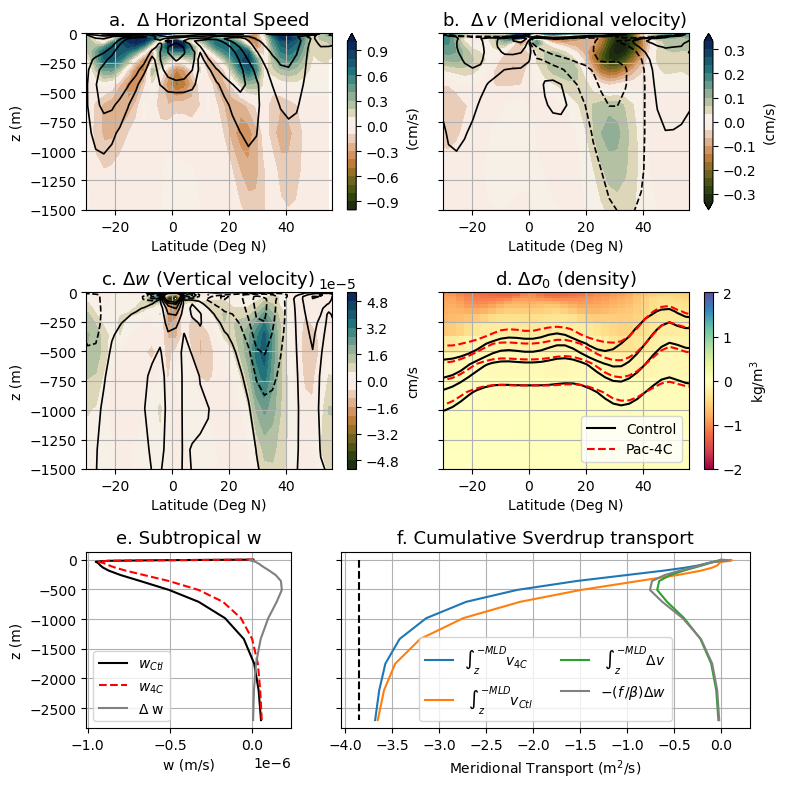

In [69]:
import matplotlib.gridspec as gridspec
# Create figure and subplots with gridspec to control width ratios

velmap = cmocean.cm.tarn

PacTr = PacPh
PacTS = PacPh
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(3, 2, figure=fig)

ylow = np.arange(20,53)
myX = np.arange(64,80)

tfon = 13

# First two rows: normal width ratio (1:1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

vm = 1
U = ax1.contourf(PacTr.YC[ylow], PacTr.Z, 100*speeddif, vmin =-vm, vmax = vm,levels = np.linspace(-vm, vm,21) , extend = 'max',cmap = velmap)
cb1 = plt.colorbar(U, ax = ax1)
ax1.contour(PacTr.YC[ylow], PacTr.Z,100*(myV**2 + myU**2)**0.5, levels = [1,2,5,10],colors = 'k', linewidths = 1.2)
ax1.set_title('a.  $\Delta$ Horizontal Speed ', fontsize = tfon) 
#ax1.set_xlabel('Latitude (Deg N)')
cb1.set_label('(cm/s)')#,fontsize=10)

vm = 1/3
A = ax2.contourf(PacTS.YG[ylow+1], PacTS.Z,100*(myVpac-myV) , vmin =-vm, vmax = vm, levels =np.linspace(-vm,vm, 21), extend = 'both', cmap = velmap) # why the weird thing? 
cb2 = plt.colorbar(A, ax = ax2)
ax2.contour(PacTS.YG[ylow+1], PacTS.Z, 100*(myV), levels = [-0.5,-0.1, 0.1, 0.5, 2], colors = 'k', linewidths = 1.2)
ax2.set_title('b.  $\Delta \, v$ (Meridional velocity) ', fontsize = tfon) 
cb2.set_label('(cm/s)')#,fontsize=10)
#ax2.set_xlabel('Latitude (Deg N)')
plt.grid()


vm = 0.000048*10/9

#plt.figure(figsize =[5,2])

myWpac = np.array(wvPac.isel(YC = ylow, XC =myX).mean('XC'))
myW = np.array(wvcon.isel(YC = ylow, XC =myX).mean('XC'))

W = ax3.contourf(PacTS.YC[ylow], PacTS.Zl,100*(myWpac-myW) , vmin =-vm, vmax = vm, levels =np.linspace(-vm, vm, 21), cmap = velmap)
cb3 = plt.colorbar(W, ax = ax3)
cb3.set_label('cm/s')
ax3.contour(PacTS.YC[ylow], PacTS.Zl, 100*(myW), levels = np.arange(-3e-4,3e-4, 5e-5), colors = 'k',linewidths = 1.2)
ax3.set_title('c. $\Delta w$ (Vertical velocity) ', fontsize = tfon)


#plt.figure(figsize =[5,4])
sigsouth =sigcon.isel(XC = myX, YC = ylow).mean('XC')
#signorth =sigcon.isel(XC = myX, YC = ylow+1)
sigPsouth = sigPac.isel(XC = myX, YC = ylow).mean('XC')
#sigPnorth = sigPac.isel(XC = myX, YC = ylow+1)

# OK finish this up real quick.
# pick a few contour levels that I want 
# this is so sketchy, I need to fix this ... 
y30 = np.argmin(np.abs(np.array(PacTS.YC[ylow]-40)))
siglevs = [sigsouth[8,y30],sigsouth[10, y30], sigsouth[11,y30], sigsouth[12,y30]] 
sigPlevs = [sigPsouth[8,y30], sigPsouth[10, y30], sigPsouth[11,y30], sigPsouth[12,y30]] 
# clev = np.linspace(-1,1,21)
I = ax4.pcolor(PacTS.YC[ylow], PacTS.Z, sigPsouth - sigsouth, vmin = -2, vmax =2,cmap = 'Spectral')
cb4 = plt.colorbar(I, ax= ax4)
cb4.set_label('kg/m$^3$')
ax4.set_title('d. $\Delta \sigma_0$ (density)', fontsize = tfon)
ax4.contour(PacTS.YC[ylow], PacTS.Z, sigsouth, colors = 'k', levels = siglevs, )
ax4.contour(PacTS.YC[ylow], PacTS.Z, sigPsouth, colors = 'r', linestyles = '--', levels = sigPlevs)
#ax4.legend(['Ctrl', 'Pac-4C'])

from matplotlib.lines import Line2D

    # Create proxy artists
legend_elements = [Line2D([0], [0], color='black', lw=1.5, label='Control'),
                    Line2D([0], [0], color='red', lw=1.5, linestyle='dashed', label='Pac-4C')]
ax4.legend(handles=legend_elements, loc='lower right')

ax4.grid()

lets = ['a','b','c','d']

for i, ax in enumerate([ax1, ax2, ax3, ax4], 1):
    #ax.set_title(f"Subplot {i}")
    ax.grid()
    ax.set_xlim([-30,56])
    ax.set_ylim([-1500,0])
    ax.set_xlabel('Latitude (Deg N)')
    #ax.text(0.05, 0.12, lets[i-1], fontsize=16, transform=ax.transAxes, ha='left', va='top')


# Third row: create subgrid with custom width ratio
sub_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[2, :], width_ratios=[1, 2]  # left thinner
)

ax5 = fig.add_subplot(sub_gs[0, 0])
ax6 = fig.add_subplot(sub_gs[0, 1])


#gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])  # Left is twice as wide

# Left subplot (wider)
#ax1 = fig.add_subplot(gs[0])
#ax1.plot(x, y1, label='sin(x)', color='blue')
#ax1.set_title('Wider Plot')
#ax1.legend()

xran2 = myX
yran2 = np.arange(40,48)
zran2 = np.arange(0,17)
zranw = np.arange(0,18)


#PlA = wvSO.isel( XC = xran, YC = yran, Zl= zran).mean('XC').mean('YC')
PlB = wvPac.isel(  XC = xran2, YC = yran2, Zl= zranw).mean('XC').mean('YC')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = wvcon.isel( XC = xran2, YC = yran2, Zl= zranw).mean('XC').mean('YC')

#ax3.set_title('w (cm/s)     ', loc = 'right', fontsize=10)
ax3.set_ylabel('z (m)')
ax1.set_ylabel('z (m)')
ax2.set_yticklabels([])
ax4.set_yticklabels([])
ax6.set_yticklabels([])


ax5.plot(Pl0, wvPac.Zl[zranw], 'k')
ax5.plot(PlB, wvPac.Zl[zranw], 'r--')
ax5.plot(PlB - Pl0, wvPac.Zl[zranw], 'gray')

ax5.legend(['$w_{Ctl}$', '$w_{4C}$', '$\\Delta$ w'])
ax5.set_title('e. Subtropical w', fontsize = tfon)
ax5.grid()
ax5.set_ylabel('z (m)')
ax5.set_xlabel('w (m/s)')

PlvP = vvPac.isel(  XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlvC = vvcon.isel( XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG')

vtr0  = PlvC  * PacTr.drF[zran2]
vtrP  = PlvP  * PacTr.drF[zran2]

# Right subplot (narrower)
#ax2 = fig.add_subplot(gs[1])
ax6.plot(np.cumsum(vtrP), PacTr.Zu[zran2])
ax6.plot(np.cumsum(vtr0), PacTr.Zu[zran2])
ax6.plot(np.cumsum(vtrP) - np.cumsum(vtr0), PacTr.Zu[zran2])
ax6.set_title('f. Cumulative Sverdrup transport', fontsize = tfon)

rad = 6371000
rot = 7.3e-5
#f= rot*2*np.sin(wvPac.YC[yran2]*np.pi/180)

# could this calculation be improved? Probably ... 
#beta = rot*2/rad*np.cos(wvPac.YC[yran2]*np.pi/180)
taux = np.load('Yohei_2018/forcing_files_jan25/taux.npy')
tauy = np.load('Yohei_2018/forcing_files_jan25/tauy.npy')
# interpolating and integrating curl(tau) with weights ... 
# using Stokes' Theorem 
tauxd = np.sum(taux[yran2[0], xran2]*np.array(SOPh.dxC.isel(XG=xran2, YC=yran2[0])) -taux[yran2[-1], xran2]*np.array(SOPh.dxC.isel(XG=xran2, YC=yran2[-1])))
tauyd = np.sum(tauy[yran2, xran2[-1]]*np.array(SOPh.dyC.isel(XC = xran2[-1], YG = yran2)) - tauy[yran2, xran2[0]]*np.array(SOPh.dyC.isel(XC = xran2[0], YG = yran2)))
tauxd2 = np.sum(taux[yran2[0]-1, xran2]*np.array(SOPh.dxC.isel(XG=xran2, YC=yran2[0]-1)) -taux[yran2[-1]+1, xran2]*np.array(SOPh.dxC.isel(XG=xran2, YC=yran2[-1]+1)))
tauyd2 = np.sum(tauy[yran2, xran2[-1]+1]*np.array(SOPh.dyC.isel(XC = xran2[-1]+1, YG = yran2)) - tauy[yran2, xran2[0]-1]*np.array(SOPh.dyC.isel(XC = xran2[0]-1, YG = yran2)))
mycurl = (tauxd+tauyd + tauxd2+ tauyd2) / np.array(SOPh.rA.isel(XC = xran2, YC = yran2).sum('XC').sum('YC')) / 2

beta= 2*np.cos(np.array(SOPh.YG[44]/180) * np.pi)/6370000 * 7.3e-5
f= rot*2*np.sin(wvPac.YC[yran2]*np.pi/180)

wdif = PlB-Pl0
#wprofP = -wvPac.isel(XC = xran2, YC = yran2, Zl= zran2).mean('XC').mean('YC') 
#wPl2 = (wprofP - wprofP[3])/np.mean(beta)*np.mean(f) 
ax6.plot(-wdif/np.mean(beta)*np.mean(f), wvPac.Zl[zranw], 'gray')

ax6.plot(0*PacTr.Zu[zran2] + mycurl/1035/beta, PacTr.Zu[zran2], 'k--')
#plt.plot(wPl2 , wvPac.Zl[zran2], 'red')
ax6.legend(['$\int_z^{-MLD} v_{4C}$ ', ' $\int_z^{-MLD} v_{Ctl}$ ' , ' $\int_z^{-MLD} \Delta v$ ', '$-(f \,/\\beta) \Delta w $'], ncol=2, fontsize = 10) #  '$\\nabla$x($\\tau)/\\rho_0 / \\beta$'], 
ax6.grid()
ax6.set_xlabel('Meridional Transport (m$^2$/s)')

#ax5.text(0.05, 0.74, 'e', fontsize=16, transform=ax5.transAxes, ha='left', va='top')
#ax6.text(0.09, 0.74, 'f', fontsize=16, transform=ax6.transAxes, ha='left', va='top')

plt.tight_layout()

#plt.savefig('eps_figures/vel_combined4_30_grids.eps',bbox_inches="tight")


## Figure Supp on Mixed Layer Depth anomalies in the control case. 

In [ ]:

# Ctl2d = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = 'Diag2d', iters = myItsTS.tolist(), ignore_unknown_vars = True)


In [3]:
CtlPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-Physical.nc'
Ctl2d = xr.open_dataset(CtlPhnc)

NameError: name 'xr' is not defined

NameError: name 'Ctl2d' is not defined

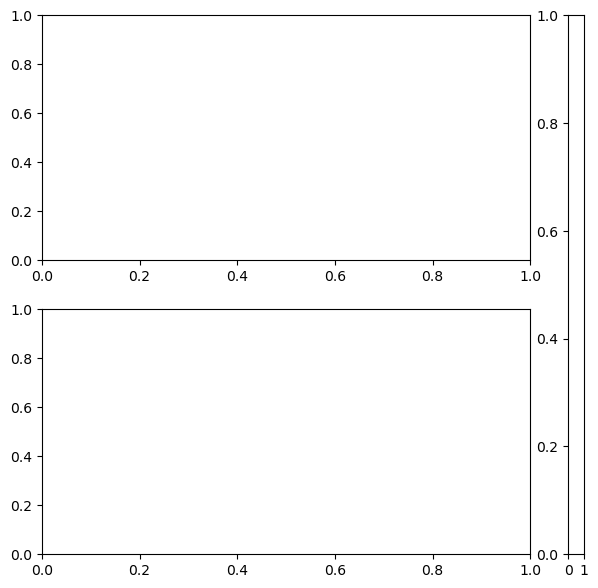

In [44]:
# Let's make a nice figure that compares the two. 

fig = plt.figure(figsize=(7, 7))

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[30, 1],   # main panels + colorbar
    wspace=0.15,
    hspace=0.2
)

# main axes
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])

# colorbar axis (spans both rows)
cax = fig.add_subplot(gs[:, 1])


#fig,axs = plt.subplots(nrows = 2, ncols=1, figsize=([6,7]))
vmin = 0
vmax = 600
toPl = Ctl2d.MXLDEPTH.isel(time = 7).where(Ctl2d.MXLDEPTH.isel(time=7)!=0, other=np.nan)
a=ax0.pcolor(Ctl2d.MXLDEPTH.XC, Ctl2d.MXLDEPTH.YC, MLDint.isel(iMONTH=7), vmin = vmin, vmax = vmax)
b=ax1.pcolor(Ctl2d.MXLDEPTH.XC, Ctl2d.MXLDEPTH.YC, toPl, vmin = vmin, vmax = vmax)

ax0.text(0.09, 0.87, 'a', fontsize=16, transform=ax0.transAxes,ha='left', va='top')
ax1.text(0.09, 0.87, 'b', fontsize=16, transform=ax1.transAxes,ha='left', va='top')
ax0.grid()
ax1.grid()
ax0.set_title('Argo Mixed Layer Depth, August mean')
ax1.set_title('MITgcm Control Mixed Layer Depth, August mean')


# shared colorbar
cb = fig.colorbar(a, cax=cax, shrink = 0.5)
cb.set_label('Mean MLD (m)')
#plt.colorbar(b, ax = axs[1], label='Mean MLD (m)')
#plt.colorbar(a, ax = axs[0], label='Mean MLD (m)')
#cax = fig.add_axes([0.92, 0.55, 0.02, 0.32])  # [left, bottom, width, height]
#cbmap = plt.colorbar(a, cax=axs[0], label='Mean MLD (m)')

#MLDdiff = Ctl2d.MXLDEPTH.isel(time=7) - MLDint.isel(iMONTH=7)

#MLDdiff.plot()
# plt.savefig('eps_figures/MLD_supp_12-22.eps', bbox_inches="tight")